# Credit Scoring PD(probability of default) Model

# Pre-Processing

In [1]:
# Kitabxanalari oxumaq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
sns.set()
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn import metrics


pd.set_option('display.max_columns', None)

In [2]:
# datani oxumaq
data=pd.read_csv(r'C:\Users\TOSHIBA\Downloads\credit_score (1).csv')
data

,ID,CustomerID,Month,Name,Age,SSN,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,TypeofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,CreditScore
0,0x1602,CUS0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,11.27,4.0,809.98,26.822620,No,49.574949,80.415295,HighspentSmallvaluepayments,312.494089,Good
1,0x1603,CUS0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,809.98,31.944960,No,49.574949,118.280222,LowspentLargevaluepayments,284.629163,Good
2,0x1604,CUS0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,NaN,4.0,809.98,28.609352,No,49.574949,81.699521,LowspentMediumvaluepayments,331.209863,Good
3,0x1605,CUS0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4.0,6.27,4.0,809.98,31.377862,No,49.574949,199.458074,LowspentSmallvaluepayments,223.451310,Good
4,0x1606,CUS0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,809.98,24.797347,No,49.574949,41.420153,HighspentMediumvaluepayments,341.489231,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87490,0x25fe8,CUS0x942c,March,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",20,6.0,9.50,3.0,502.38,39.323569,No,35.104023,140.581403,HighspentMediumvaluepayments,410.256158,Poor
87491,0x25fe9,CUS0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",23,7.0,11.50,3.0,502.38,34.663572,No,35.104023,60.971333,HighspentLargevaluepayments,479.866228,Poor
87492,0x25fea,CUS0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",18,7.0,11.50,3.0,502.38,40.565631,No,35.104023,54.185950,HighspentMediumvaluepayments,496.651610,Poor
87493,0x25feb,CUS0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,5729,2,"Auto Loan, and Student Loan",27,6.0,11.50,3.0,502.38,41.255522,No,35.104023,24.028477,HighspentLargevaluepayments,516.809083,Poor


In [3]:
# descriptive statistika
data.describe(include='all')

,ID,CustomerID,Month,Name,Age,SSN,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,TypeofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,CreditScore
count,87495,87495,87495,78779,87495.000000,87495,81317,8.749500e+04,74319.000000,87495.000000,87495.000000,87495.000000,87495.000000,77583,87495.000000,81400.000000,85654.000000,85789.000000,87495.000000,87495.000000,87495,87495.000000,79786.000000,87495,86437.000000,87495
unique,87495,12500,8,10139,NaN,12501,15,NaN,NaN,NaN,NaN,NaN,NaN,6260,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,7,NaN,3
top,0x1602,CUS0xd40,January,Langep,NaN,#F%$D@*&8,Lawyer,NaN,NaN,NaN,NaN,NaN,NaN,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,NaN,LowspentSmallvaluepayments,NaN,Standard
freq,1,8,10970,41,NaN,4857,5762,NaN,NaN,NaN,NaN,NaN,NaN,1208,NaN,NaN,NaN,NaN,NaN,NaN,45810,NaN,NaN,22237,NaN,46651
mean,NaN,NaN,NaN,NaN,110.467364,NaN,NaN,1.802404e+05,4193.181285,17.112646,22.664792,73.050871,7.019841,NaN,21.060403,30.904324,10.385851,27.734302,1426.716635,32.290526,NaN,1388.517947,195.482486,NaN,402.281023,NaN
std,NaN,NaN,NaN,NaN,686.549658,NaN,NaN,1.455212e+06,3179.195651,117.428586,129.806747,467.727237,60.352339,NaN,14.864558,225.495250,6.776714,193.011903,1155.824064,5.112418,NaN,8248.832131,199.357752,NaN,213.309331,NaN
min,NaN,NaN,NaN,NaN,-500.000000,NaN,NaN,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,0.000000,NaN,-5.000000,-3.000000,-6.490000,0.000000,0.230000,20.000000,NaN,0.000000,0.000000,NaN,0.007760,NaN
25%,NaN,NaN,NaN,NaN,24.000000,NaN,NaN,1.943348e+04,1626.677917,3.000000,4.000000,8.000000,1.000000,NaN,10.000000,9.000000,5.340000,3.000000,566.400000,28.059063,NaN,30.453014,72.220853,NaN,270.107156,NaN
50%,NaN,NaN,NaN,NaN,33.000000,NaN,NaN,3.757975e+04,3095.905000,6.000000,5.000000,13.000000,3.000000,NaN,18.000000,14.000000,9.410000,6.000000,1166.230000,32.322206,NaN,69.285581,128.921405,NaN,336.698600,NaN
75%,NaN,NaN,NaN,NaN,42.000000,NaN,NaN,7.288608e+04,5967.930000,7.000000,7.000000,20.000000,5.000000,NaN,28.000000,18.000000,14.840000,9.000000,1948.980000,36.495606,NaN,161.405543,236.802042,NaN,470.180816,NaN


In [4]:
data.columns

Index(['ID', 'CustomerID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'AnnualIncome', 'MonthlyInhandSalary', 'NumBankAccounts',
       'NumCreditCard', 'InterestRate', 'NumofLoan', 'TypeofLoan',
       'Delayfromduedate', 'NumofDelayedPayment', 'ChangedCreditLimit',
       'NumCreditInquiries', 'OutstandingDebt', 'CreditUtilizationRatio',
       'PaymentofMinAmount', 'TotalEMIpermonth', 'Amountinvestedmonthly',
       'PaymentBehaviour', 'MonthlyBalance', 'CreditScore'],
      dtype='str')

In [5]:
# lazimsiz sutunlar drop olunur
data=data.drop(['ID', 'CustomerID','Name','SSN','TypeofLoan'],axis=1)

In [6]:
# asili deyishenin yaradilmasi

# credit score sutununda 3 deyer var : good , poor ve standart.
# score adli sutun yaradilir, hardaki credit_score sutunun deyerleri poor deyilse 0 yazilir , poor olanlar 1 yazilir
# yeni yaradilan score sutunu olur asili deyishen ve 2 deyeri olur 0 ve 1

data['score'] = np.where(data['CreditScore']=='Poor',1,0)

In [7]:
data.drop('CreditScore',axis=1,inplace=True)

In [8]:
# score sutunun deyerleri sayi value_counts() ile yoxlayiriq
data['score'].value_counts()

score
0    62145
1    25350
Name: count, dtype: int64

In [9]:
# data-da missing deyeleri yoxlayiriq, varsa evez edirik ( mean , min, max, mode and etc. )

# P.s for loop ile yazilmasi ustunlukdur
data.isnull().sum()

Month                         0
Age                           0
Occupation                 6178
AnnualIncome                  0
MonthlyInhandSalary       13176
NumBankAccounts               0
NumCreditCard                 0
InterestRate                  0
NumofLoan                     0
Delayfromduedate              0
NumofDelayedPayment        6095
ChangedCreditLimit         1841
NumCreditInquiries         1706
OutstandingDebt               0
CreditUtilizationRatio        0
PaymentofMinAmount            0
TotalEMIpermonth              0
Amountinvestedmonthly      7709
PaymentBehaviour              0
MonthlyBalance             1058
score                         0
dtype: int64

In [10]:
data.dtypes

Month                         str
Age                         int64
Occupation                    str
AnnualIncome              float64
MonthlyInhandSalary       float64
NumBankAccounts             int64
NumCreditCard               int64
InterestRate                int64
NumofLoan                   int64
Delayfromduedate            int64
NumofDelayedPayment       float64
ChangedCreditLimit        float64
NumCreditInquiries        float64
OutstandingDebt           float64
CreditUtilizationRatio    float64
PaymentofMinAmount            str
TotalEMIpermonth          float64
Amountinvestedmonthly     float64
PaymentBehaviour              str
MonthlyBalance            float64
score                       int64
dtype: object

In [11]:
for i in data.columns:
    if data[i].dtype=='str':
        data[i]=data[i].fillna(data[i].mode()[0])
      
    else:
        data[i]=data[i].fillna(data[i].mean())

In [12]:
# Numeric ve categoric deyishenlerin  her biri uchun WoE transformation olunur
for var in data.columns:
    if var == 'score':
        continue  

    if data[var].dtypes != 'str':
        
        q1 = data[var].quantile(0.25)
        q2 = data[var].quantile(0.5)
        q3 = data[var].quantile(0.75)

        ranges = [-np.inf, q1, q2, q3, np.inf]
        data['category_' + var] = pd.cut(data[var], bins=ranges, duplicates='drop')

        grouped = data.groupby(['category_' + var, 'score'])['score'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data = data.merge(grouped[['category_' + var, var + '_woe']], how='left', on='category_' + var)

    elif data[var].dtypes =='str':

        grouped = data.groupby([var, 'score'])['score'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data = data.merge(grouped[[var, var + '_woe']], how='left', on=var)

In [13]:
# datada sutunlar uzre paylanma (normal or not normal distribution) yoxlanilir.
from scipy import stats
for i in data.columns:
    if data[i].dtype in ['int64','float64']:
        kstest_statistic,kstest_p_value=stats.kstest(data[i],'norm')
        print(f'column:{i}')
        print(f'p_value:{kstest_p_value}')
        if kstest_p_value>0.05:
            print('data is normally')
            print()
        else:
            print('data is not normally')
            print()

column:Age
p_value:0.0
data is not normally

column:AnnualIncome
p_value:0.0
data is not normally

column:MonthlyInhandSalary
p_value:0.0
data is not normally

column:NumBankAccounts
p_value:0.0
data is not normally

column:NumCreditCard
p_value:0.0
data is not normally

column:InterestRate
p_value:0.0
data is not normally

column:NumofLoan
p_value:0.0
data is not normally

column:Delayfromduedate
p_value:0.0
data is not normally

column:NumofDelayedPayment
p_value:0.0
data is not normally

column:ChangedCreditLimit
p_value:0.0
data is not normally

column:NumCreditInquiries
p_value:0.0
data is not normally

column:OutstandingDebt
p_value:0.0
data is not normally

column:CreditUtilizationRatio
p_value:0.0
data is not normally

column:TotalEMIpermonth
p_value:0.0
data is not normally

column:Amountinvestedmonthly
p_value:0.0
data is not normally

column:MonthlyBalance
p_value:0.0
data is not normally

column:score
p_value:0.0
data is not normally

column:Month_woe
p_value:0.0
data is no

In [14]:
# korrelasiya baxilir. 10%den yuxari target ile asili olan ve oz aralarinda 70% den ashaqi asili olan deyishenleri saxlayiriq
import pandas as pd

def target_correlation(data, target, threshold=0.1):
    
    woe_features = data.filter(regex=r'_woe$', axis=1)
    woe_features[target] = data[target]
    
    corr_matrix = woe_features.corr(method='spearman', numeric_only=True)
    
    target_corr = corr_matrix[target]
    variables_explaining_target = (
        target_corr[abs(target_corr) > threshold]
        .drop(target, errors='ignore')
        .index
        .tolist()
    )
    
    result_explaining_target = (
        pd.DataFrame({
            'Variable': variables_explaining_target,
            'Correlation with Target': corr_matrix.loc[variables_explaining_target, target]
        })
        .reset_index(drop=True)
    )
    
    return result_explaining_target


target_result = target_correlation(data, 'score')

target_result

,Variable,Correlation with Target
0,Age_woe,-0.102439
1,AnnualIncome_woe,-0.199462
2,MonthlyInhandSalary_woe,-0.174459
3,NumBankAccounts_woe,-0.262026
4,NumCreditCard_woe,-0.314837
5,InterestRate_woe,-0.406848
6,NumofLoan_woe,-0.287626
7,Delayfromduedate_woe,-0.338427
8,NumofDelayedPayment_woe,-0.222047
9,NumCreditInquiries_woe,-0.360778


In [15]:
def intercorrelation(data, target, threshold=0.7):
    
    woe_features = data.filter(regex=r'_woe$', axis=1).copy()
    
    corr_matrix = woe_features.corr(method='spearman', numeric_only=True)
    
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    
    high_corr = corr_matrix.where(mask).stack().reset_index()
    high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]
    
    high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]
    
    return high_corr.reset_index(drop=True)


intercorrelated_result = intercorrelation(data, 'score', threshold=0.7)
intercorrelated_result

,Variable 1,Variable 2,Correlation
0,AnnualIncome_woe,MonthlyInhandSalary_woe,0.729928


In [16]:
target_result.Variable.tolist()

['Age_woe',
 'AnnualIncome_woe',
 'MonthlyInhandSalary_woe',
 'NumBankAccounts_woe',
 'NumCreditCard_woe',
 'InterestRate_woe',
 'NumofLoan_woe',
 'Delayfromduedate_woe',
 'NumofDelayedPayment_woe',
 'NumCreditInquiries_woe',
 'OutstandingDebt_woe',
 'PaymentofMinAmount_woe',
 'PaymentBehaviour_woe',
 'MonthlyBalance_woe']

In [17]:
data_woe=data[['Age_woe',
 'AnnualIncome_woe',
 'MonthlyInhandSalary_woe',
 'NumBankAccounts_woe',
 'NumCreditCard_woe',
 'InterestRate_woe',
 'NumofLoan_woe',
 'Delayfromduedate_woe',
 'NumofDelayedPayment_woe',
 'NumCreditInquiries_woe',
 'OutstandingDebt_woe',
 'PaymentofMinAmount_woe',
 'PaymentBehaviour_woe',
 'MonthlyBalance_woe','score']]

In [18]:
# musteqil ve asili deyishenleri sechin input ve output olaraq

In [19]:
inputs=data_woe.drop('score',axis=1)
target=data_woe['score']

# Modeling

In [20]:
# data train test bolgusu olunur, test_size=0.3 goturulur.
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(inputs,target,test_size=0.3,random_state=42)

In [21]:
# Confusion matrix, auc ve gini hesablanacaq funksiya qurun 
from sklearn.metrics import precision_score, recall_score, roc_auc_score

def evaluate(model, X_train, y_train, X_test, y_test):
    
    '''Predictions and probabilities for the training set'''
    
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    '''Predictions and probabilities for the test set'''
    
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    '''Calculate metrics for the training set''' 
    
    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)

    '''Calculate metrics for the test set'''
    
    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)

    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],
        'Precision': [precision_train, precision_test],
        'Recall': [recall_train, recall_test]
    })

    confusion_matrix = metrics.confusion_matrix(y_test, y_test_pred)
    
    return results , confusion_matrix

In [22]:
# Logistic regression modeli qurulur
clf=LogisticRegression()
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
# Funksiya vasitesile oyrenmish modelin neticelerine baxin ( Gini, confusion matrix)
result=evaluate(clf,X_train, y_train, X_test, y_test)
result

(  Dataset       Gini  Precision    Recall
 0   Train  59.412159   0.636006  0.566932
 1    Test  58.741700   0.628088  0.558082,
 array([[16067,  2529],
        [ 3382,  4271]]))

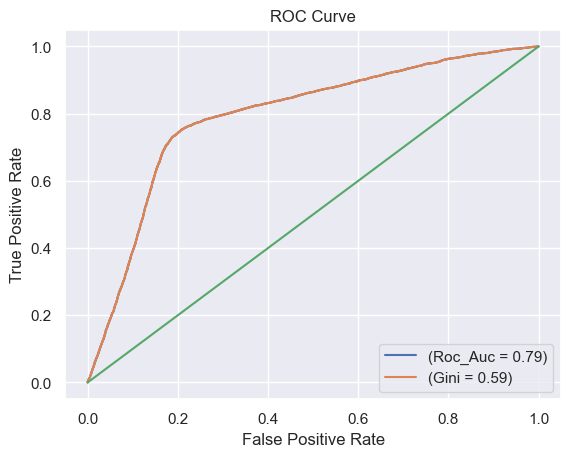

In [24]:
# Alinmish gini score uchun roc curve qrafiki yaradin.
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = clf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
gini = (2*roc_auc_score(y_test, y_prob))-1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()

plt.plot(fpr, tpr, label='(Roc_Auc = %0.2f)' % roc_auc)
plt.plot(fpr, tpr, label='(Gini = %0.2f)' % gini)
plt.plot([0, 1], [0, 1])
plt.xlim()
plt.ylim()

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend(loc='lower right')
plt.show()

# Univariate analysis of Gini

In [25]:
# Her bir variable uchun Gini deyerini train ve test uzre gosterin
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Create lists to store the variables, ROC AUC scores, and Gini scores
variables = []
train_gini_scores = []
test_gini_scores = []


for i in X_train.columns:
    X_train_single_var = X_train[[i]]
    X_test_single_var = X_test[[i]]

    # Fit a classifier using the single variable on the training set
    clf.fit(X_train_single_var, y_train)
    y_pred_train_single_var = clf.predict_proba(X_train_single_var)[:, 1]

    # Calculate ROC AUC score for the single variable model on the training set
    train_roc = roc_auc_score(y_train, y_pred_train_single_var)

    # Calculate Gini score for the single variable model on the training set
    train_gini = 2 * train_roc - 1

    # Fit a classifier using the single variable on the test set
    y_pred_test_single_var = clf.predict_proba(X_test_single_var)[:, 1]

    # Calculate ROC AUC score for the single variable model on the test set
    test_roc = roc_auc_score(y_test, y_pred_test_single_var)

    # Calculate Gini score for the single variable model on the test set
    test_gini = 2 * test_roc - 1

    # Append the results to the lists
    variables.append(i)
    train_gini_scores.append(train_gini)
    test_gini_scores.append(test_gini)

# Create a DataFrame from the results
results_df = pd.DataFrame({
    'Variable': variables,
    'Train Gini': train_gini_scores,
    'Test Gini': test_gini_scores
})

# Sort the DataFrame by Test Gini score in descending order
results_df_sorted = results_df.sort_values(by='Test Gini', ascending=False)

# Display the results
pd.options.display.float_format = '{:.4f}'.format
#pd.options.display.float_format = '{:.4%}'.format


results_df_sorted


,Variable,Train Gini,Test Gini
10,OutstandingDebt_woe,0.5153,0.5117
5,InterestRate_woe,0.5002,0.5011
9,NumCreditInquiries_woe,0.4459,0.4376
7,Delayfromduedate_woe,0.4229,0.4030
4,NumCreditCard_woe,0.3885,0.3752
6,NumofLoan_woe,0.3542,0.3531
3,NumBankAccounts_woe,0.3173,0.3229
11,PaymentofMinAmount_woe,0.3041,0.2976
8,NumofDelayedPayment_woe,0.2730,0.2740
1,AnnualIncome_woe,0.2478,0.2412


# Secilmish variable-lar ile yeni model

In [26]:
# Univariate analysisde test uzre GINI deyeri 40 faizden yuxari olan deyishenler saxlanilaraq yeni model qurulur
input_1=data_woe[['OutstandingDebt_woe', 'InterestRate_woe', 'NumCreditInquiries_woe',
       'Delayfromduedate_woe']]
output=data_woe['score']



In [27]:
X_train_uni,X_test_uni,y_train_uni,y_test_uni=train_test_split(input_1,output,random_state=42,test_size=0.3)

In [28]:
clf_uni=LogisticRegression()
clf_uni.fit(X_train_uni,y_train_uni)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
result1=evaluate(clf_uni,X_train_uni,y_train_uni,X_test_uni,y_test_uni)
result

(  Dataset    Gini  Precision  Recall
 0   Train 59.4122     0.6360  0.5669
 1    Test 58.7417     0.6281  0.5581,
 array([[16067,  2529],
        [ 3382,  4271]]))

# Deployment with woe

In [30]:
# Verilmish prod_data_with_woe.xlsx uchun modeli deploy edin.

# model.predict_proba() vasitesile mushterilerin default etme ehtimalini gosterin (PD)

In [31]:
df=pd.read_excel(r'C:\Users\TOSHIBA\Downloads\prod_data_with_woe (1).xlsx')
df

,Unnamed: 0,Age_woe,AnnualIncome_woe,MonthlyInhandSalary_woe,NumBankAccounts_woe,NumCreditCard_woe,InterestRate_woe,NumofLoan_woe,Delayfromduedate_woe,NumofDelayedPayment_woe,NumCreditInquiries_woe,OutstandingDebt_woe,MonthlyBalance_woe,PaymentofMinAmount_woe,PaymentBehaviour_woe
0,66072,-0.1156,0.6777,0.6042,0.3233,0.0409,-0.0280,-0.1058,-1.0948,0.3325,1.1029,-0.3521,0.6836,0.9738,0.3910
1,6931,-0.1156,0.2314,-0.4757,0.3233,0.0409,-0.0280,0.3208,-0.1009,-0.2813,0.5585,-0.3521,-0.2370,-0.4725,-0.0706
2,3064,-0.0589,-0.1881,0.1639,0.7752,0.0409,-1.3762,0.9065,1.0508,0.6511,0.5585,-0.3521,0.6836,0.9738,0.1827
3,9134,-0.2219,0.2314,0.1639,-0.7832,-1.2249,-0.0280,0.3208,0.4968,0.3325,-1.0683,-1.2232,-0.4900,-0.4725,-0.3158
4,47254,-0.1156,-0.1881,-0.1572,-0.7832,0.0409,-1.3762,-0.1058,-1.0948,-0.6423,-0.4761,-1.2232,0.6836,-0.0110,0.1827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,52892,-0.2219,0.2314,-0.1572,-0.3802,-1.2249,-0.0280,-0.1058,-1.0948,-0.6423,-1.0683,-1.2232,0.2145,-0.4725,-0.3158
796,53553,0.4878,-0.1881,0.1639,0.3233,-0.0785,0.9632,0.3208,1.0508,-0.2813,1.1029,-0.3521,0.2145,-0.0110,0.3910
797,39282,-0.2219,-0.1881,-0.1572,-0.7832,-0.0785,-1.3762,-0.9635,-1.0948,-0.6423,-0.4761,-1.2232,-0.2370,-0.4725,-0.0034
798,53283,-0.0589,-0.5447,-0.4757,0.3233,-1.2249,-0.0280,0.9065,-0.1009,-0.2813,-0.4761,-1.2232,-0.4900,-0.0110,-0.3158


In [32]:
df=df.rename({'Unnamed: 0':'Customer_ID'},axis=1)

In [33]:
df

,Customer_ID,Age_woe,AnnualIncome_woe,MonthlyInhandSalary_woe,NumBankAccounts_woe,NumCreditCard_woe,InterestRate_woe,NumofLoan_woe,Delayfromduedate_woe,NumofDelayedPayment_woe,NumCreditInquiries_woe,OutstandingDebt_woe,MonthlyBalance_woe,PaymentofMinAmount_woe,PaymentBehaviour_woe
0,66072,-0.1156,0.6777,0.6042,0.3233,0.0409,-0.0280,-0.1058,-1.0948,0.3325,1.1029,-0.3521,0.6836,0.9738,0.3910
1,6931,-0.1156,0.2314,-0.4757,0.3233,0.0409,-0.0280,0.3208,-0.1009,-0.2813,0.5585,-0.3521,-0.2370,-0.4725,-0.0706
2,3064,-0.0589,-0.1881,0.1639,0.7752,0.0409,-1.3762,0.9065,1.0508,0.6511,0.5585,-0.3521,0.6836,0.9738,0.1827
3,9134,-0.2219,0.2314,0.1639,-0.7832,-1.2249,-0.0280,0.3208,0.4968,0.3325,-1.0683,-1.2232,-0.4900,-0.4725,-0.3158
4,47254,-0.1156,-0.1881,-0.1572,-0.7832,0.0409,-1.3762,-0.1058,-1.0948,-0.6423,-0.4761,-1.2232,0.6836,-0.0110,0.1827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,52892,-0.2219,0.2314,-0.1572,-0.3802,-1.2249,-0.0280,-0.1058,-1.0948,-0.6423,-1.0683,-1.2232,0.2145,-0.4725,-0.3158
796,53553,0.4878,-0.1881,0.1639,0.3233,-0.0785,0.9632,0.3208,1.0508,-0.2813,1.1029,-0.3521,0.2145,-0.0110,0.3910
797,39282,-0.2219,-0.1881,-0.1572,-0.7832,-0.0785,-1.3762,-0.9635,-1.0948,-0.6423,-0.4761,-1.2232,-0.2370,-0.4725,-0.0034
798,53283,-0.0589,-0.5447,-0.4757,0.3233,-1.2249,-0.0280,0.9065,-0.1009,-0.2813,-0.4761,-1.2232,-0.4900,-0.0110,-0.3158


In [34]:
df=df[['Customer_ID','OutstandingDebt_woe', 'InterestRate_woe', 'NumCreditInquiries_woe',
       'Delayfromduedate_woe']]

In [35]:
df['PD'] = clf_uni.predict_proba(df.iloc[:,1:])[:,1]

df

,Customer_ID,OutstandingDebt_woe,InterestRate_woe,NumCreditInquiries_woe,Delayfromduedate_woe,PD
0,66072,-0.3521,-0.0280,1.1029,-1.0948,0.3352
1,6931,-0.3521,-0.0280,0.5585,-0.1009,0.3050
2,3064,-0.3521,-1.3762,0.5585,1.0508,0.3587
3,9134,-1.2232,-0.0280,-1.0683,0.4968,0.4700
4,47254,-1.2232,-1.3762,-0.4761,-1.0948,0.6796
...,...,...,...,...,...,...
795,52892,-1.2232,-0.0280,-1.0683,-1.0948,0.5838
796,53553,-0.3521,0.9632,1.1029,1.0508,0.1512
797,39282,-1.2232,-1.3762,-0.4761,-1.0948,0.6796
798,53283,-1.2232,-0.0280,-0.4761,-0.1009,0.4729


# Deployment with real values (homework)

In [ ]:
# Verilmish test_data_real_values.xlsx uchun modeli deploy edin. 

# verilmish test datasinda mushterilerin default etme ehtimalini gosterin (PD)

In [36]:
test_data=pd.read_excel(r'C:\Users\TOSHIBA\Downloads\test_data_real_values (2).xlsx')
test_data

,OutstandingDebt,InterestRate,NumCreditInquiries,Delayfromduedate,CustomerID
0,632.9300,17,0,20,53115
1,3259.1700,24,11,53,35538
2,2313.6000,22,11,55,15150
3,556.8500,16,8,23,65145
4,1115.0600,6,3,16,23224
...,...,...,...,...,...
995,1360.3100,11,8,6,86109
996,1213.2600,11,6,22,62411
997,1509.7200,27,11,18,5554
998,356.6900,18,9,25,70288


In [37]:
columns_to_process = ['OutstandingDebt','InterestRate', 'NumCreditInquiries', 'Delayfromduedate']

for i in columns_to_process:
    ranges = [-np.inf, data[i].quantile(0.25), data[i].quantile(0.5), data[i].quantile(0.75), np.inf]  
    test_data[f'category_{i}'] = pd.cut(test_data[i], bins=ranges)
    test_data = test_data.merge(data[[f'category_{i}', f'{i}_woe']].drop_duplicates(subset=f'category_{i}'), how='left', on=f'category_{i}')

test_data

,OutstandingDebt,InterestRate,NumCreditInquiries,Delayfromduedate,CustomerID,category_OutstandingDebt,OutstandingDebt_woe,category_InterestRate,InterestRate_woe,category_NumCreditInquiries,NumCreditInquiries_woe,category_Delayfromduedate,Delayfromduedate_woe
0,632.9300,17,0,20,53115,"(566.4, 1166.23]",1.2096,"(13.0, 20.0]",-0.0280,"(-inf, 3.0]",1.1029,"(18.0, 28.0]",-0.1009
1,3259.1700,24,11,53,35538,"(1948.98, inf]",-1.2232,"(20.0, inf]",-1.3762,"(9.0, inf]",-1.0683,"(28.0, inf]",-1.0948
2,2313.6000,22,11,55,15150,"(1948.98, inf]",-1.2232,"(20.0, inf]",-1.3762,"(9.0, inf]",-1.0683,"(28.0, inf]",-1.0948
3,556.8500,16,8,23,65145,"(-inf, 566.4]",1.2719,"(13.0, 20.0]",-0.0280,"(6.0, 9.0]",-0.4761,"(18.0, 28.0]",-0.1009
4,1115.0600,6,3,16,23224,"(566.4, 1166.23]",1.2096,"(-inf, 8.0]",0.9632,"(-inf, 3.0]",1.1029,"(10.0, 18.0]",0.4968
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1360.3100,11,8,6,86109,"(1166.23, 1948.98]",-0.3521,"(8.0, 13.0]",1.1494,"(6.0, 9.0]",-0.4761,"(-inf, 10.0]",1.0508
996,1213.2600,11,6,22,62411,"(1166.23, 1948.98]",-0.3521,"(8.0, 13.0]",1.1494,"(3.0, 6.0]",0.5585,"(18.0, 28.0]",-0.1009
997,1509.7200,27,11,18,5554,"(1166.23, 1948.98]",-0.3521,"(20.0, inf]",-1.3762,"(9.0, inf]",-1.0683,"(10.0, 18.0]",0.4968
998,356.6900,18,9,25,70288,"(-inf, 566.4]",1.2719,"(13.0, 20.0]",-0.0280,"(6.0, 9.0]",-0.4761,"(18.0, 28.0]",-0.1009


In [41]:
input_1.columns

Index(['OutstandingDebt_woe', 'InterestRate_woe', 'NumCreditInquiries_woe',
       'Delayfromduedate_woe'],
      dtype='str')

In [42]:
test_data=test_data[['CustomerID','OutstandingDebt_woe', 'InterestRate_woe', 'NumCreditInquiries_woe',
       'Delayfromduedate_woe']]
test_data

,CustomerID,OutstandingDebt_woe,InterestRate_woe,NumCreditInquiries_woe,Delayfromduedate_woe
0,53115,1.2096,-0.0280,1.1029,-0.1009
1,35538,-1.2232,-1.3762,-1.0683,-1.0948
2,15150,-1.2232,-1.3762,-1.0683,-1.0948
3,65145,1.2719,-0.0280,-0.4761,-0.1009
4,23224,1.2096,0.9632,1.1029,0.4968
...,...,...,...,...,...
995,86109,-0.3521,1.1494,-0.4761,1.0508
996,62411,-0.3521,1.1494,0.5585,-0.1009
997,5554,-0.3521,-1.3762,-1.0683,0.4968
998,70288,1.2719,-0.0280,-0.4761,-0.1009


In [44]:
prob = clf_uni.predict_proba(test_data.iloc[:,1:])[:,1]

In [45]:
test_data['PD'] = prob

test_data

,CustomerID,OutstandingDebt_woe,InterestRate_woe,NumCreditInquiries_woe,Delayfromduedate_woe,PD
0,53115,1.2096,-0.0280,1.1029,-0.1009,0.1481
1,35538,-1.2232,-1.3762,-1.0683,-1.0948,0.7135
2,15150,-1.2232,-1.3762,-1.0683,-1.0948,0.7135
3,65145,1.2719,-0.0280,-0.4761,-0.1009,0.2055
4,23224,1.2096,0.9632,1.1029,0.4968,0.0876
...,...,...,...,...,...,...
995,86109,-0.3521,1.1494,-0.4761,1.0508,0.2017
996,62411,-0.3521,1.1494,0.5585,-0.1009,0.2100
997,5554,-0.3521,-1.3762,-1.0683,0.4968,0.5049
998,70288,1.2719,-0.0280,-0.4761,-0.1009,0.2055
